In [2]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

In [3]:
llm = HuggingFaceEndpoint(
    repo_id="google/gemma-4-31B-it",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

/Users/harshraj/Desktop/LangGraph/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
class uni_llmState(TypedDict):
    input: str
    output: str

In [11]:
def llm_output_gen(state: uni_llmState) -> uni_llmState:
    prompt = state['input']
    response = model.invoke(prompt)
    state['output'] = response.content
    return state

In [14]:
graph = StateGraph(uni_llmState)

graph.add_node("LLM Generation",llm_output_gen)
graph.add_edge(START, "LLM Generation")
graph.add_edge("LLM Generation", END)

workflow = graph.compile()

In [15]:
# Graph execution
intial_state = {'input': 'How far is moon from the earth?'}

final_state = workflow.invoke(intial_state)

print(final_state['output'])

On average, the Moon is about **238,855 miles** (384,400 kilometers) away from Earth.

However, because the Moon follows an elliptical (oval-shaped) orbit rather than a perfect circle, this distance changes constantly:

*   **Perigee (Closest approach):** When the Moon is closest to Earth, it is about **225,623 miles** (363,104 km) away. This is often when we see a "Supermoon."
*   **Apogee (Farthest point):** When the Moon is farthest from Earth, it is about **252,087 miles** (405,696 km) away.

**To put that distance into perspective:**
You could fit all seven other planets of our solar system side-by-side in the gap between the Earth and the Moon, and you would still have a little bit of


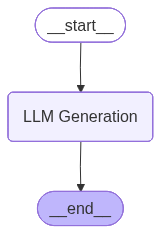

In [16]:
workflow